# Part 1 - How good is the v0 model?

A while back I set out to rebuild xwOBA from scratch as a Bayesian model. What came out is what I'm calling **v0**: a BART (Bayesian Additive Regression Trees) categorical model that predicts a batted ball's outcome from just three contact measurements — launch speed, launch angle, and sprint speed — and rolls those probabilities up into an expected-wOBA number for each hitter. That's the same information set public Baseball Savant xwOBA is built on, so the very first thing I want to know is: did I actually reproduce it?

Before doing anything clever with the model, let me check how faithful it is. I'll load the run artifacts from `results/stage_{A,B,C}/` and take a look.

The short version: player-season correlation with Savant lands around **0.96** (for hitters with 100+ PA), calibration error is about **0.04**, and — this surprised me — the quality saturates early, by roughly 50k training rows (Stage B). Stage C, on 100k rows, matches it within noise.

In [1]:
# --- setup: locate the repo and import the shared notebook helpers (run this first) ---
import sys
from pathlib import Path

_root = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "config.yaml").exists()), Path.cwd())
sys.path.insert(0, str(_root / "notebooks"))
from nb_helpers import ROOT, RESULTS, jload, show_fig

import polars as pl
from IPython.display import Markdown, display

print("repo root:", ROOT)
print("results:  ", RESULTS, "(exists)" if RESULTS.exists() else "(MISSING)")

repo root: C:\Users\H-100\Desktop\python\xwobart
results:   C:\Users\H-100\Desktop\python\xwobart\results (exists)


## Quality across the three fit stages

I fit the model in three stages. Stage A is a tiny smoke run (5k rows) — just enough to check the wiring, so I expect weak numbers there. The real comparison is B (50k rows) versus C (100k rows). If C looks about the same as B, that tells me the model is already data-saturated by ~50k rows and there's little point paying for more.

One caveat on the table below: ELPD isn't comparable across stages, since each one predicts a different number of held-out events.

In [2]:
rows = []
for stage in ("stage_A", "stage_B", "stage_C"):
    m = jload(f"{stage}/metrics.json")
    rep, elpd = m["replication"], m["elpd"]
    rows.append({
        "stage": stage.replace("stage_", ""),
        "fit_rows": m.get("fit_rows"),
        "player_r_holdout": round(rep["player_r_holdout"], 4),
        "event_r_holdout": round(rep["event_r_holdout"], 4),
        "calib_ece": round(m["calibration"]["per_class"]["out"]["ece"], 4),
        "elpd_lppd": round(elpd["elpd_lppd"], 0),
        "elpd_se": round(elpd["elpd_se"], 0),
    })
pl.DataFrame(rows)

stage,fit_rows,player_r_holdout,event_r_holdout,calib_ece,elpd_lppd,elpd_se
"""A""",5000,0.5065,0.8925,0.0635,-13819.0,99.0
"""B""",50000,0.9628,0.9162,0.0381,-80023.0,246.0
"""C""",100000,0.956,0.9105,0.0424,-80107.0,244.0


For Stage C, `elpd_lppd` comes in at **−80107 ± 244** over 122k holdout events — that's the anchor any future model version has to beat. Notice that player r barely climbs from A to C and ELPD hardly moves at all: three features get you most of the way there, and they get you there fast.

## Feature importance

So which of the three features is doing the work? pymc-BART adds features to the surface one at a time, most important first, and tracks the cumulative R² — how much of the full model's explanatory power is recovered at each step.

In [3]:
vi = jload("stage_C/metrics.json")["variable_importance"]
order = vi["raw"]["indices"]                       # features in importance order
names = [vi["feature_labels"][i] for i in order]
pl.DataFrame({"features used": [names[0]] + [f"+ {n}" for n in names[1:]],
              "cumulative r2": [round(x, 4) for x in vi["raw"]["r2_mean"]]})

features used,cumulative r2
"""launch_angle""",0.8526
"""+ launch_speed""",0.8609
"""+ sprint_speed""",0.8621


Launch angle alone recovers R² 0.853 — it separates grounders from line drives from flies, which *is* most of the outcome. Adding launch speed gets to 0.861, and sprint speed contributes about +0.001. Keep that last number in mind for the sprint figure below: the model should show only a small speed effect, and it does.

## The pictures (Stage C)

Numbers are one thing; let me actually look at what the model is doing. First the headline plot — model xwOBA against public Savant xwOBA, one point per player-season. What to look for: how tightly the points hug the diagonal.

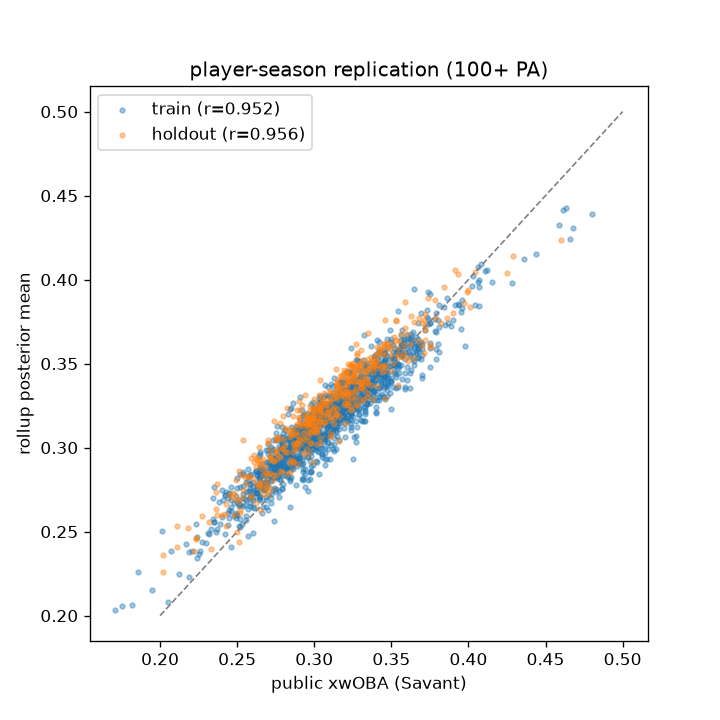

*Player-season xwOBA, model vs Savant — the tight diagonal is the r ≈ 0.96.*

In [4]:
show_fig("stage_C/figures/replication_player.png",
         caption="Player-season xwOBA, model vs Savant — the tight diagonal is the r ≈ 0.96.")

That tight diagonal is the 0.96 correlation — the model faithfully tracks Savant.

Next, calibration. Within each outcome class, the plot bins events by predicted probability and asks how often the outcome actually happened. What to look for: points on the dashed 45° line mean the probabilities are honest, not just well-ordered (ECE ≈ 0.04). Home runs are the one visible wobble — under-predicted in the top bin.

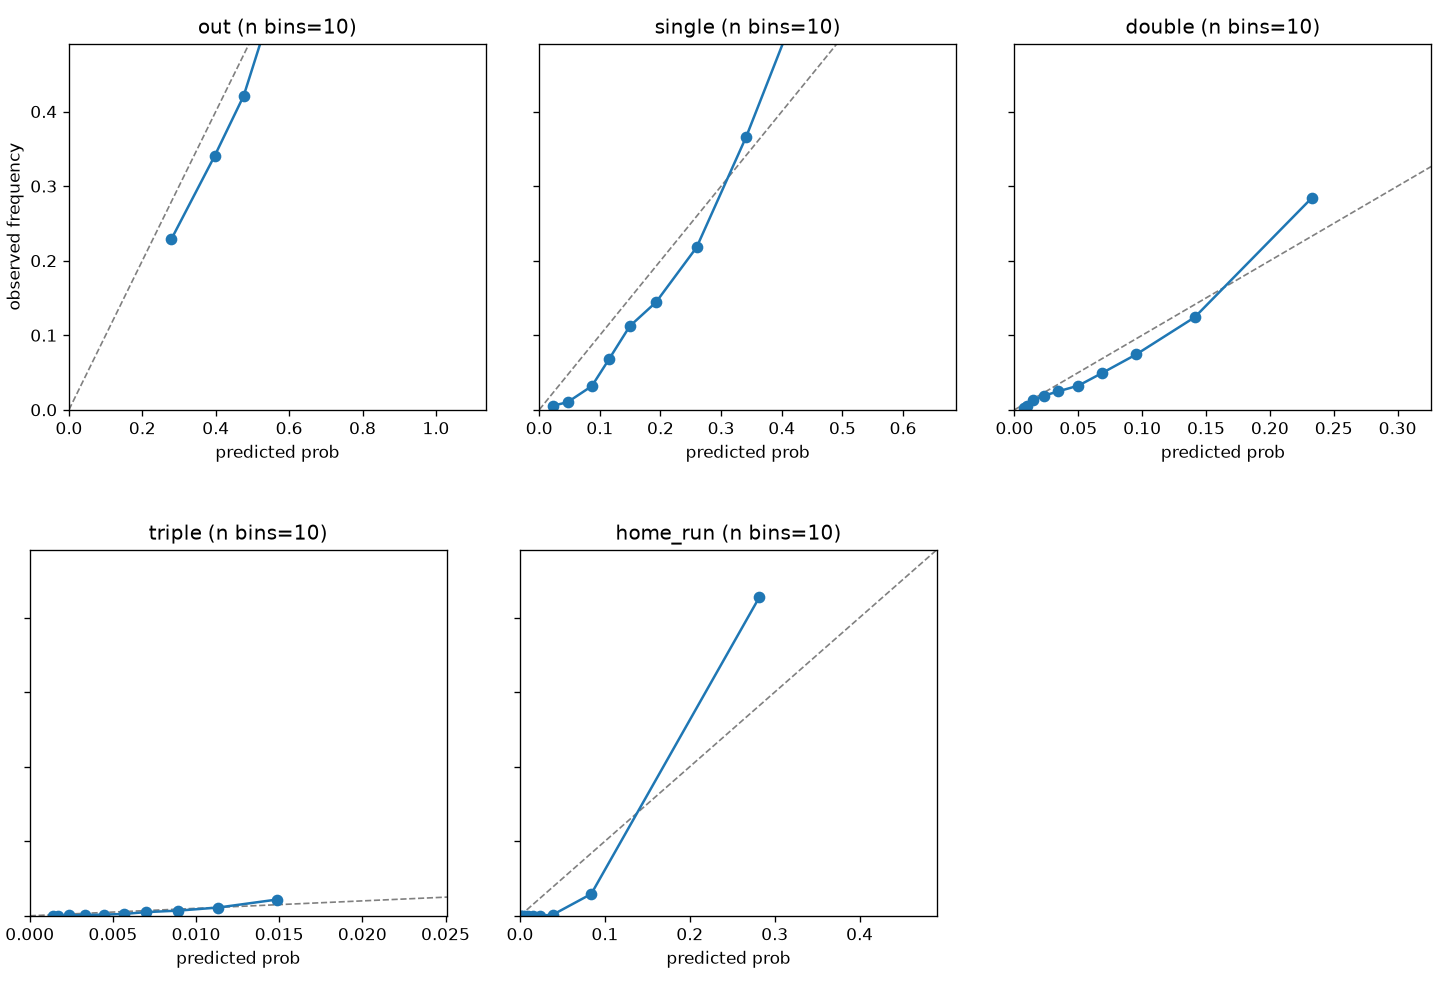

*Reliability by outcome class — points on the dashed diagonal mean honest probabilities.*

In [5]:
show_fig("stage_C/figures/calibration_reliability.png",
         caption="Reliability by outcome class — points on the dashed diagonal mean honest probabilities.")

The probabilities check out. Now a chart to read *backwards* — the sprint-speed sanity check, where the flat line is the point.

Freeze two batted balls — a topped grounder (85 mph at −10°) and a barrel (103 mph at 28°) — and vary only the batter's sprint speed. Speed should matter on the grounder (a fast runner beats the throw for an infield single) and do nothing on the barrel (nobody outruns a ball hit into the seats). A sloppy surface would smear a "fast players are good" bonus over everything; a flat barrel curve means the model localized the effect where the game actually pays it. And remember from the table above: sprint speed adds ~0.001 R², so the grounder effect *should* be small.

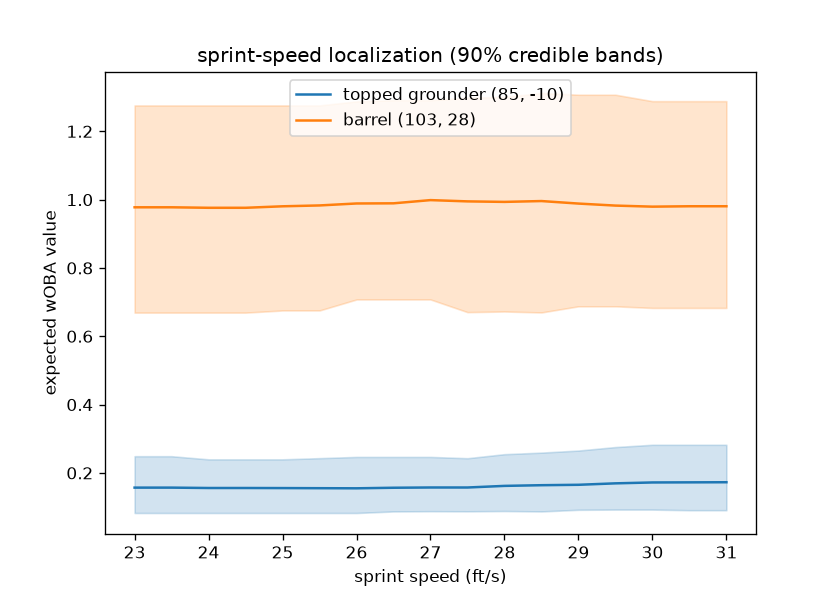

*Expected wOBA of one frozen batted ball vs sprint speed — grounder slope +0.0023 wOBA per ft/s, barrel +0.0009.*

In [6]:
loc = jload("stage_C/metrics.json")["localization"]
show_fig("stage_C/figures/sprint_localization_curves.png",
         caption=f"Expected wOBA of one frozen batted ball vs sprint speed — grounder slope "
                 f"{loc['grounder_slope_per_ftps']:+.4f} wOBA per ft/s, barrel {loc['barrel_slope_per_ftps']:+.4f}.")

Exactly as it should be: weak topped contact gains value as the runner speeds up, barrels don't budge. The held-out events agree — on real topped balls, expected value correlates 0.03 with sprint speed; on real barrels, 0.002.

Last picture: pymc-BART's own view of the same importance story, drawn from the posterior. The x axis adds features most-important-first — launch angle, then + launch speed, then + sprint speed (in this render the tick labels are bare feature indices 1, + 0, + 2). What to look for: the curve is already at the dashed full-model line after one feature.

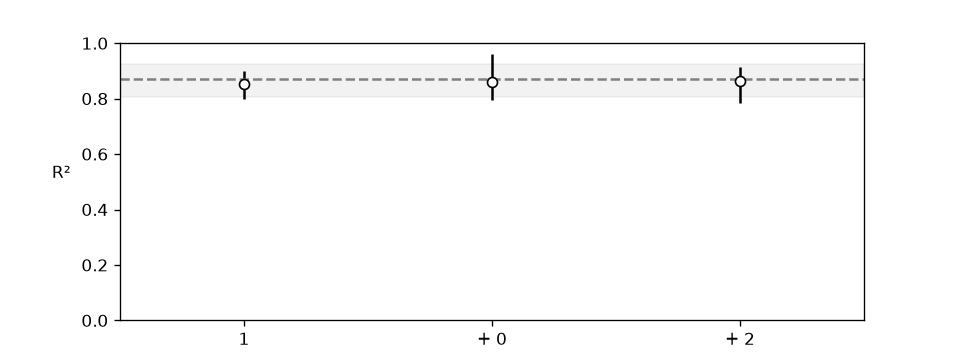

*Cumulative R² as features join, most important first — launch angle carries it; sprint speed is the +0.001 at the end.*

In [7]:
show_fig("stage_C/figures/variable_importance.png",
         caption="Cumulative R² as features join, most important first — launch angle carries it; sprint speed is the +0.001 at the end.")

## Takeaway

So v0 is a faithful, well-calibrated reconstruction of xwOBA from three contact features. That's reassuring — but it raises the obvious next question: is it any *more accurate* than Savant itself, or did I just rebuild the same thing? That's what Part 2 is about.

In [8]:
# guard: the headline numbers quoted in the prose above, checked against the artifacts
# under results/ — fails loudly instead of letting the text silently drift out of date.
mC = jload("stage_C/metrics.json")
assert round(mC["replication"]["player_r_holdout"], 2) == 0.96          # "lands around 0.96"
assert round(mC["calibration"]["per_class"]["out"]["ece"], 2) == 0.04   # "calibration error about 0.04"
assert round(mC["elpd"]["elpd_lppd"]) == -80107 and round(mC["elpd"]["elpd_se"]) == 244
assert round(mC["elpd"]["n_events"] / 1000) == 122                      # "over 122k holdout events"
vi_raw = mC["variable_importance"]["raw"]
assert vi_raw["indices"][0] == 1                                        # launch_angle enters first
assert [round(x, 3) for x in vi_raw["r2_mean"]] == [0.853, 0.861, 0.862]
mloc = mC["localization"]
assert round(mloc["weak_topped_sprint_corr"], 2) == 0.03 and round(mloc["solid_barrel_sprint_corr"], 3) == 0.002
print("prose numbers still match the artifacts")

prose numbers still match the artifacts
